In [52]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv('bangladesh_student_performance_updated.csv')

In [54]:
df.shape


(2018, 16)

In [55]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
375,29/04/2018,M,18.0,Urban,GT3,Together,2,0,At_home,Health,Yes,No,84963.0,1,3.31,2.63
1321,29/04/2018,M,18.0,Rural,GT3,Together,0,4,Health,Teacher,No,No,36992.0,5,2.77,2.36
1405,29/04/2018,M,17.0,Rural,GT3,Together,2,3,Health,Health,No,Yes,50106.0,1,2.57,2.29
748,29/04/2018,F,18.0,Rural,GT3,Together,2,4,Health,Farmer,No,No,40029.0,2,5.00,4.48
929,29/04/2018,M,18.0,Urban,GT3,Apart,1,2,Other,Health,No,No,73768.0,4,3.29,2.75
1604,29/04/2018,M,18.0,Urban,LE3,Together,0,4,NaN,Services,No,No,72983.0,2,3.29,2.68
868,29/04/2018,F,19.0,Rural,GT3,Apart,0,2,Teacher,Farmer,No,No,44343.0,4,3.99,3.07
1578,29/04/2018,F,17.0,Urban,GT3,Together,1,3,Services,Services,No,No,108634.0,5,3.58,2.91
1936,29/04/2018,M,18.0,Urban,GT3,Together,4,3,Health,Farmer,No,No,86722.0,2,3.63,3.44
1821,29/04/2018,M,17.0,Rural,GT3,Together,2,0,Services,Farmer,No,Yes,50448.0,3,4.13,3.46


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   str    
 1   gender        2018 non-null   str    
 2   age           1983 non-null   float64
 3   address       1983 non-null   str    
 4   famsize       2018 non-null   str    
 5   Pstatus       2018 non-null   str    
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   str    
 9   F_Job         2018 non-null   str    
 10  relationship  2018 non-null   str    
 11  smoker        2018 non-null   str    
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), str(9)
memory usage: 340.4 KB


In [57]:
df['time_friends'].unique()
df['M_Edu'].unique()
df['famsize'].unique()

<ArrowStringArray>
['GT3', 'LE3']
Length: 2, dtype: str

In [58]:
df.isnull().sum()

date             0
gender           0
age             35
address         35
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           35
F_Job            0
relationship     0
smoker           0
tuition_fee     35
time_friends     0
ssc_result       0
hsc_result       0
dtype: int64

In [59]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

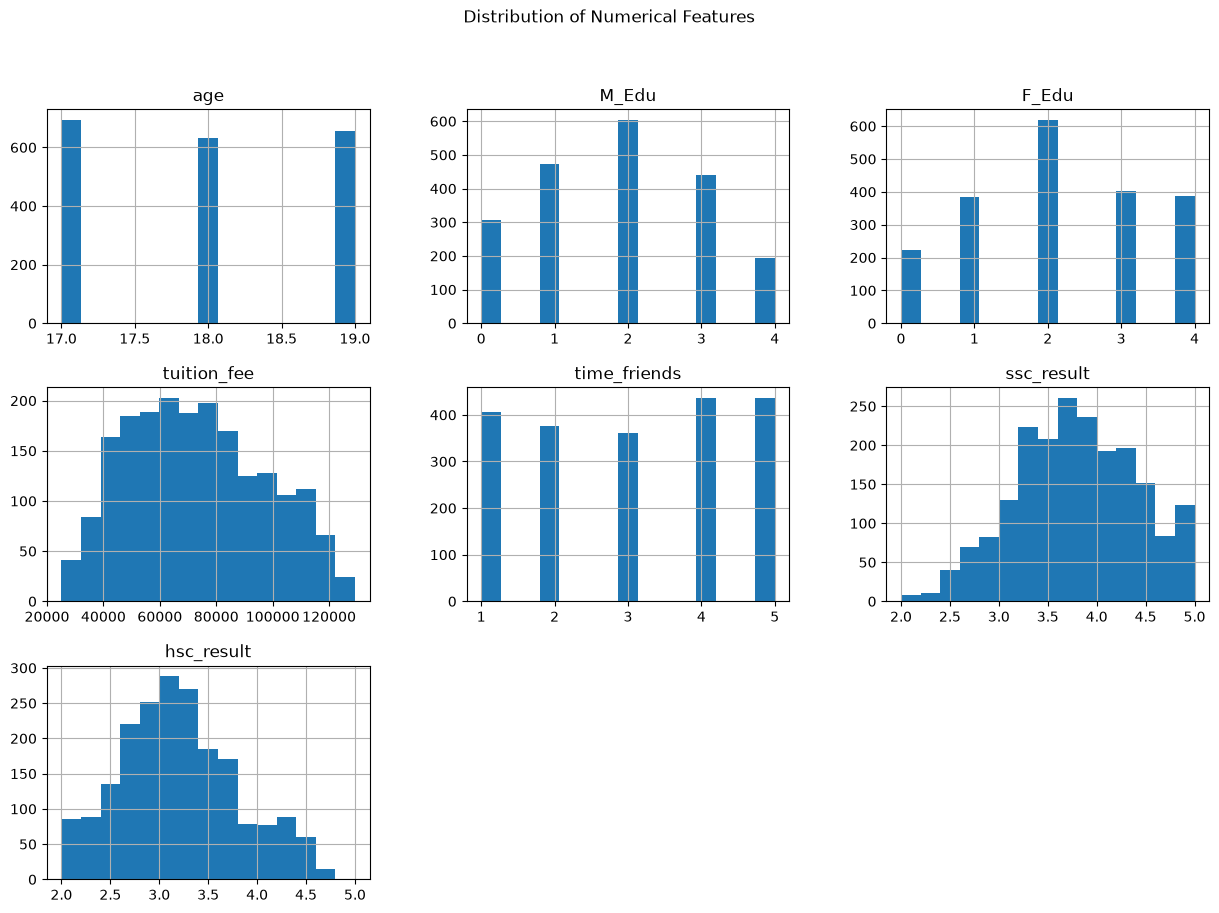

In [60]:
df.hist(bins = 15, figsize = (15,10))

plt.suptitle('Distribution of Numerical Features')
plt.show()

In [61]:
numerical_cols = ['age', 'tuition_fee', 'ssc_result', 'hsc_result']

df[numerical_cols].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


Text(0.5, 1.0, 'Correlation heatmap of Numerical Columns')

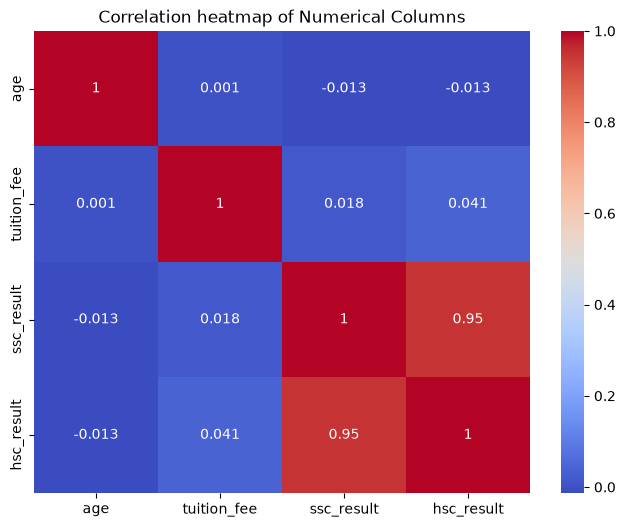

In [62]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
)

plt.title("Correlation heatmap of Numerical Columns")

<Axes: xlabel='age'>

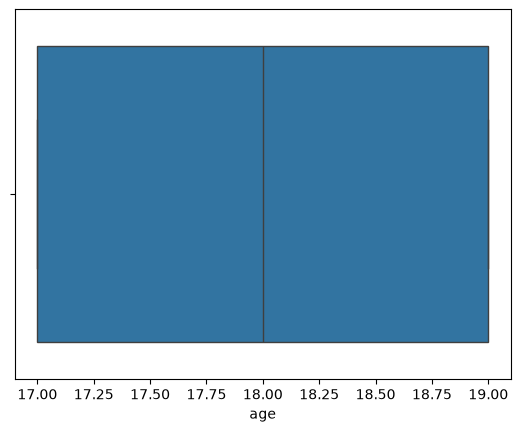

In [63]:
sns.boxplot(data = df, x='age')

# Pre processing

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder,LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

In [65]:
nominal_cat = ['gender' , 'address', 'famsize', 'Pstatus', 'relationship', 'smoker', 'M_Job', 'F_Job']
# ordinal_cat = ['M_Edu', 'F_Edu', 'time_friends']

# M_edu_order = ['0', '1', '2', '3', '4']
# F_edu_order = ['0', '1', '2', '3', '4']
# time_friends_order = ['5','4', '3', '2', '1']

numerical_col = ['age', 'tuition_fee', 'ssc_result']

In [66]:
numerical_transformers = Pipeline(
    steps =[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
    )
 

In [67]:
nominal_transformers = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(sparse_output = False, handle_unknown = 'ignore'))
    ]
)
 

In [68]:
# ordinal_transformers = Pipeline(
#     steps = [
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('encoder', OrdinalEncoder(categories = [M_edu_order, F_edu_order, time_friends_order])),
#         ('scaler', MinMaxScaler())
#     ]
# )
 

In [69]:
preprocessor = ColumnTransformer(
    transformers = [
        ('numerical', numerical_transformers, numerical_col), 
        ('nominal', nominal_transformers, nominal_cat),
        # ('ordinal', ordinal_transformers, ordinal_cat)
    ],
    remainder = 'passthrough'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('nominal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [70]:
X = df.drop(['date', 'hsc_result'], axis = 1)
y = df['hsc_result']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)



In [71]:
X_train

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
746,M,19.0,Rural,LE3,Together,2,2,Other,Services,No,No,49318.0,3,4.95
1381,M,17.0,Urban,GT3,Together,0,1,Health,Farmer,No,Yes,88032.0,5,2.68
240,F,17.0,Urban,GT3,Together,4,3,Other,Services,No,No,116230.0,4,3.75
1646,M,18.0,Urban,LE3,Apart,2,1,Other,Business,No,No,79334.0,3,3.70
1460,M,18.0,Rural,GT3,Apart,4,3,At_home,Farmer,No,No,80248.0,2,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,F,18.0,Rural,GT3,Together,2,2,At_home,Health,No,No,50003.0,1,3.83
1294,F,19.0,Urban,LE3,Together,2,3,At_home,Farmer,Yes,No,110895.0,2,3.30
860,F,19.0,Rural,GT3,Together,0,2,Health,Farmer,No,No,51576.0,1,5.00
1459,F,18.0,Rural,GT3,Together,2,4,Other,Services,No,No,45830.0,1,4.42


In [72]:
y_train

746     4.43
1381    2.07
240     3.11
1646    2.91
1460    3.66
        ... 
1130    3.26
1294    2.72
860     4.57
1459    3.79
1126    3.07
Name: hsc_result, Length: 1614, dtype: float64

# LineaRegression

In [73]:
from sklearn.linear_model import LinearRegression, SGDRegressor

In [76]:
lr_pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['gender','age','address',...,'tuition_fee','time_friends','ssc_result']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('nominal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [77]:
lr_pipe.predict(X_test)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [80]:
sgd_pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)

sgd_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['gender','age','address',...,'tuition_fee','time_friends','ssc_result']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('nominal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [81]:
sgd_pipe.predict(X_test)

array([3.2254135 , 3.79727037, 3.85239543, 3.95110468, 3.85229576,
       3.36426474, 3.94815009, 2.52569868, 1.98402053, 3.29680904,
       3.69373143, 2.94856318, 3.25809786, 4.29898439, 3.08401564,
       2.6468759 , 3.72704317, 3.39902273, 2.84115353, 2.95271301,
       2.85240516, 3.23700663, 2.97443356, 3.21835637, 1.93056368,
       2.50619288, 3.2389493 , 3.83547761, 3.06010515, 3.96719124,
       2.43102705, 3.97939729, 4.27994693, 2.60755256, 3.23376461,
       3.29804766, 2.78414432, 3.70059572, 2.52075515, 2.62485074,
       3.11759442, 3.00343175, 3.75900801, 2.78576558, 2.14574808,
       3.11115472, 2.67277756, 2.61690341, 3.98944938, 3.24866297,
       3.0753354 , 3.47723181, 4.21803465, 3.64049137, 3.06919711,
       3.17319014, 3.32980512, 2.67970896, 3.84000263, 2.62031662,
       3.05490243, 2.79106307, 2.50302431, 4.45249868, 2.60712106,
       3.23701531, 3.93346403, 2.69557796, 3.06473507, 3.21899879,
       3.05367858, 2.76381879, 2.6394569 , 3.67996642, 3.09794

In [82]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

In [85]:
# linear regression
y_pred = lr_pipe.predict(X_test)

print(f'MSE: {round(mean_squared_error(y_test, y_pred),4)}')
print(f'R2: {round(r2_score(y_test, y_pred),4)}')
print(f'RMSE: {round(root_mean_squared_error(y_test, y_pred),4)}')
print(f'MAE: {round(mean_absolute_error(y_test, y_pred),4)}')


MSE: 0.0203
R2: 0.9459
RMSE: 0.1425
MAE: 0.1114


In [86]:
# linear regression
y_pred = sgd_pipe.predict(X_test)

print(f'MSE: {round(mean_squared_error(y_test, y_pred),4)}')
print(f'R2: {round(r2_score(y_test, y_pred),4)}')
print(f'RMSE: {round(root_mean_squared_error(y_test, y_pred),4)}')
print(f'MAE: {round(mean_absolute_error(y_test, y_pred),4)}')


MSE: 0.0207
R2: 0.9448
RMSE: 0.1438
MAE: 0.1135
